# Training Machine Learning With the produced segmanent windows from EDA Part.

In [1]:
import pickle
from pathlib import Path
import numpy as np
import utils
import utils_visual

# Step 1: Get the training and test sets from the output directory

In [2]:
cache_path = Path("outputs/cache/segmented.pkl")
with open(cache_path, "rb") as f:
    data = pickle.load(f)

train_mask = data["train_mask"]
test_mask = data["test_mask"]
Windows = data["windows"]
labels_arr = data["labels"]

# Step 2: More Data Preperation Before the ML Training.

In [3]:
#Scalling the test and training set mixed scaling is used in this model

train_set, test_set = utils.MixedScaling(train_mask, test_mask, Windows)
labels_train = labels_arr[train_mask]
labels_test = labels_arr[test_mask]

Έτοιμα Train δεδομένα με σχήμα: (3012, 1200)
Έτοιμα Test δεδομένα με σχήμα: (1494, 1200)


# Step 3: Model Training. In this section we are going to train 3 models SVM Gradient Boosting and Logic Regression

In [4]:
gradient_model,predict0 = utils.GradientBoosting(train_set, labels_train, test_set, labels_test)
svm_model,predict1 =utils.SVM(train_set, labels_train, test_set, labels_test)
logic_regression_model,predict2=utils.LogicRegression(train_set, labels_train, test_set, labels_test)

✔️ Το Gradient Boosting εκπαιδεύτηκε επιτυχώς.
Έναρξη εκπαίδευσης SVM... Παρακαλώ περιμένετε.
✔️ Το SVM εκπαιδεύτηκε επιτυχώς.
Έναρξη εκπαίδευσης Logistic Regression... Παρακαλώ περιμένετε.


/home/stamylaptop/Documents/GitHub/social-media-gesture-recognition/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


✔️ Η Λογιστική Παλινδρόμηση εκπαιδεύτηκε επιτυχώς.


/home/stamylaptop/Documents/GitHub/social-media-gesture-recognition/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Step 4: Evaluating models



 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: Gradient Boosting

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.00      0.00      0.00       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.02      0.02      0.02       299
 swipe-right       0.04      0.06      0.05       296
     texting       0.68      0.94      0.79       299

    accuracy                           0.20      1494
   macro avg       0.15      0.20      0.17      1494
weighted avg       0.15      0.20      0.17      1494

[2] Ανάλυση True/False Θετικών και Αρνητικών ανά Χειρονομία:
  • Χειρονομία 'scroll-down':
    - True Positives (TP) : 0  (Σωστή πρόβλεψη της κίνησης)
    - False Positives (FP): 335  (Άλλη κίνηση που μπερδεύτηκε ως 'scroll-down')
    - False Negatives (FN): 301  (Πραγματικό 'scroll-down' που χάθηκε)
    - True Negatives (TN) : 858  (Σωστή απόρριψη μη σχετικών κινήσεων)

  • Χειρονομία 'scroll-up':
    - True Positives (TP) : 0  (Σωστή 

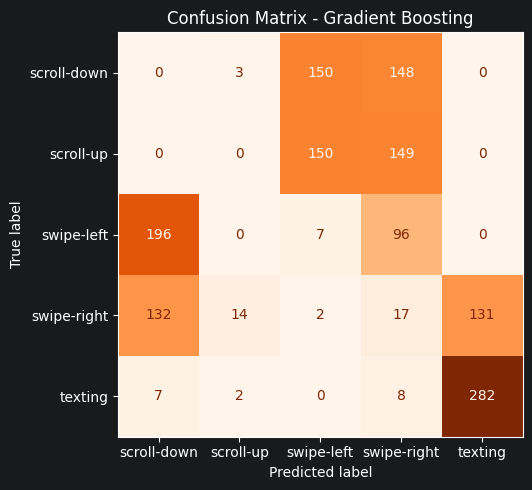


 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: Support Vector Machine

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.11      0.29      0.16       301
   scroll-up       0.00      0.00      0.00       299
  swipe-left       0.00      0.00      0.00       299
 swipe-right       0.00      0.00      0.00       296
     texting       0.52      0.48      0.50       299

    accuracy                           0.15      1494
   macro avg       0.13      0.15      0.13      1494
weighted avg       0.13      0.15      0.13      1494

[2] Ανάλυση True/False Θετικών και Αρνητικών ανά Χειρονομία:
  • Χειρονομία 'scroll-down':
    - True Positives (TP) : 86  (Σωστή πρόβλεψη της κίνησης)
    - False Positives (FP): 670  (Άλλη κίνηση που μπερδεύτηκε ως 'scroll-down')
    - False Negatives (FN): 215  (Πραγματικό 'scroll-down' που χάθηκε)
    - True Negatives (TN) : 523  (Σωστή απόρριψη μη σχετικών κινήσεων)

  • Χειρονομία 'scroll-up':
    - True Positives (TP) : 0  (

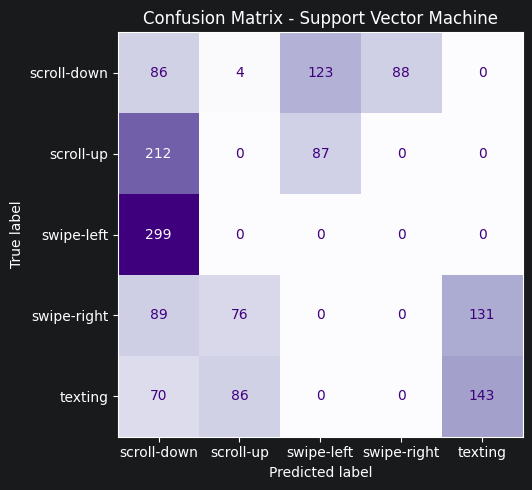


 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: Logistic Regression

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.19      0.30      0.23       301
   scroll-up       0.10      0.10      0.10       299
  swipe-left       0.35      0.34      0.35       299
 swipe-right       0.18      0.23      0.20       296
     texting       0.87      0.17      0.29       299

    accuracy                           0.23      1494
   macro avg       0.34      0.23      0.23      1494
weighted avg       0.34      0.23      0.23      1494

[2] Ανάλυση True/False Θετικών και Αρνητικών ανά Χειρονομία:
  • Χειρονομία 'scroll-down':
    - True Positives (TP) : 91  (Σωστή πρόβλεψη της κίνησης)
    - False Positives (FP): 392  (Άλλη κίνηση που μπερδεύτηκε ως 'scroll-down')
    - False Negatives (FN): 210  (Πραγματικό 'scroll-down' που χάθηκε)
    - True Negatives (TN) : 801  (Σωστή απόρριψη μη σχετικών κινήσεων)

  • Χειρονομία 'scroll-up':
    - True Positives (TP) : 30  (Σω

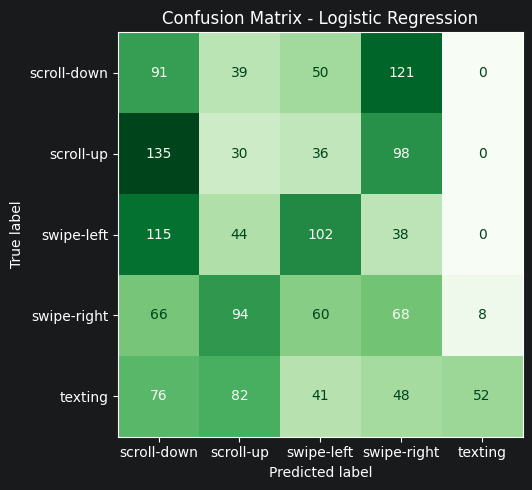

In [5]:
utils_visual.ModelEvaluation(
    model_name="Gradient Boosting",
    test_labels=labels_test,
    y_pred=predict0,
    classes=gradient_model.classes_,
    cmap="Oranges"
)

# Αξιολόγηση για το Support Vector Machine (SVM)
utils_visual.ModelEvaluation(
    model_name="Support Vector Machine",
    test_labels=labels_test,
    y_pred=predict1,
    classes=svm_model.classes_,
    cmap="Purples"
)

# Αξιολόγηση για τη Logistic Regression
utils_visual.ModelEvaluation(
    model_name="Logistic Regression",
    test_labels=labels_test,
    y_pred=predict2,
    classes=logic_regression_model.classes_,
    cmap="Greens"
)

# Fine Tunning.


 ΕΝΑΡΞΗ GRID SEARCH: GRADIENT_BOOSTING
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 2
min_resources_: 400
max_resources_: 4506
aggressive_elimination: True
factor: 4
----------
iter: 0
n_candidates: 18
n_resources: 400
Fitting 1 folds for each of 18 candidates, totalling 18 fits
----------
iter: 1
n_candidates: 5
n_resources: 400
Fitting 1 folds for each of 5 candidates, totalling 5 fits
----------
iter: 2
n_candidates: 2
n_resources: 1600
Fitting 1 folds for each of 2 candidates, totalling 2 fits
✔️ Το Grid Search για το gradient_boosting ολοκληρώθηκε!
-> Καλύτερες Παράμετροι: {'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_depth': 3}
-> Καλύτερο Validation F1-Score: 0.2338


 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: Tuned Gradient Boosting

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       1.00      1.00      1.00       301
   scroll-up       1.00      1.00      1.00       299
  swipe-left       1.00      1.00      1.00      

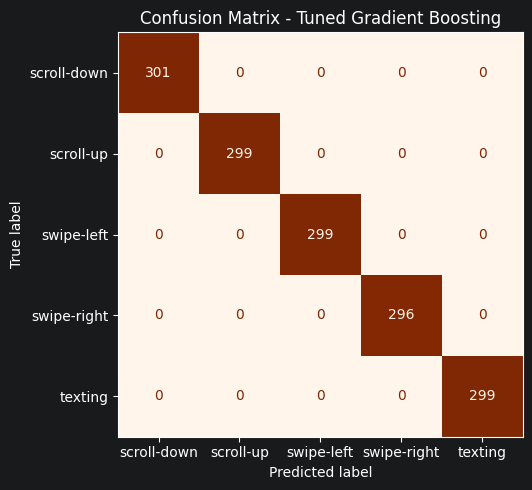


 ΕΝΑΡΞΗ GRID SEARCH: SVM
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 2
min_resources_: 400
max_resources_: 4506
aggressive_elimination: True
factor: 4
----------
iter: 0
n_candidates: 18
n_resources: 400
Fitting 1 folds for each of 18 candidates, totalling 18 fits
----------
iter: 1
n_candidates: 5
n_resources: 400
Fitting 1 folds for each of 5 candidates, totalling 5 fits
----------
iter: 2
n_candidates: 2
n_resources: 1600
Fitting 1 folds for each of 2 candidates, totalling 2 fits
✔️ Το Grid Search για το svm ολοκληρώθηκε!
-> Καλύτερες Παράμετροι: {'C': 0.1, 'gamma': 'auto', 'kernel': 'linear'}
-> Καλύτερο Validation F1-Score: 0.1767


 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: Tuned SVM

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.49      0.73      0.59       301
   scroll-up       0.57      0.41      0.48       299
  swipe-left       0.92      0.81      0.86       299
 swipe-right       0.78      0.82      0.80       296


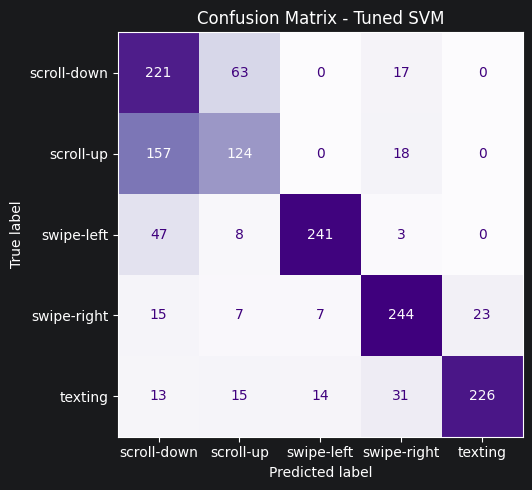


 ΕΝΑΡΞΗ GRID SEARCH: LOGISTIC_REGRESSION
n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 400
max_resources_: 4506
aggressive_elimination: True
factor: 4
----------
iter: 0
n_candidates: 8
n_resources: 400
Fitting 1 folds for each of 8 candidates, totalling 8 fits


/home/stamylaptop/Documents/GitHub/social-media-gesture-recognition/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/stamylaptop/Documents/GitHub/social-media-gesture-recognition/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/stamylaptop/Documents/GitHub/social-media-gesture-recognition/.venv/lib/python3.

----------
iter: 1
n_candidates: 2
n_resources: 1600
Fitting 1 folds for each of 2 candidates, totalling 2 fits


/home/stamylaptop/Documents/GitHub/social-media-gesture-recognition/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/stamylaptop/Documents/GitHub/social-media-gesture-recognition/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://

✔️ Το Grid Search για το logistic_regression ολοκληρώθηκε!
-> Καλύτερες Παράμετροι: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
-> Καλύτερο Validation F1-Score: 0.2163


 ΣΤΑΤΙΣΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ: Tuned Logistic Regression

[1] Classification Report:
              precision    recall  f1-score   support

 scroll-down       0.49      0.68      0.57       301
   scroll-up       0.52      0.48      0.50       299
  swipe-left       0.88      0.89      0.89       299
 swipe-right       0.77      0.63      0.69       296
     texting       0.86      0.74      0.79       299

    accuracy                           0.68      1494
   macro avg       0.70      0.68      0.69      1494
weighted avg       0.70      0.68      0.69      1494

[2] Ανάλυση True/False Θετικών και Αρνητικών ανά Χειρονομία:
  • Χειρονομία 'scroll-down':
    - True Positives (TP) : 204  (Σωστή πρόβλεψη της κίνησης)
    - False Positives (FP): 210  (Άλλη κίνηση που μπερδεύτηκε ως 'scroll-down')
    - False Negatives (FN):

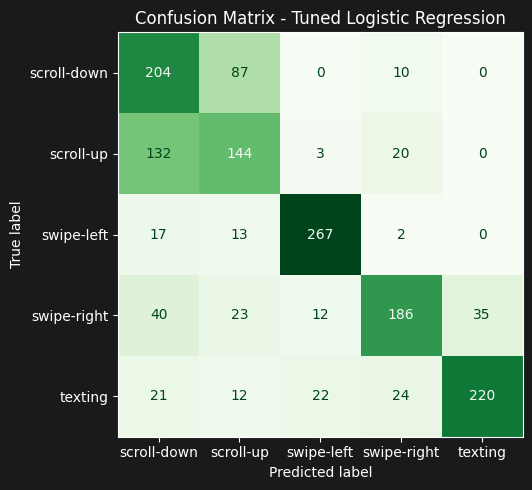

In [6]:
# 1. Fine-Tuning για το Gradient Boosting
gradient_model_best = utils.Fine_Tunning('gradient_boosting', train_set, labels_train, test_set, labels_test)
preds_gb = gradient_model_best.predict(test_set)
utils_visual.ModelEvaluation("Tuned Gradient Boosting", labels_test, preds_gb, gradient_model_best.classes_, cmap="Oranges")

# 2. Fine-Tuning για το Support Vector Machine (SVM)
best_svm = utils.Fine_Tunning('svm', train_set, labels_train, test_set, labels_test)
preds_svm = best_svm.predict(test_set)
utils_visual.ModelEvaluation("Tuned SVM", labels_test, preds_svm, best_svm.classes_, cmap="Purples")

# 3. Fine-Tuning για τη Logistic Regression
best_lr = utils.Fine_Tunning('logistic_regression', train_set, labels_train, test_set, labels_test)
preds_lr = best_lr.predict(test_set)
utils_visual.ModelEvaluation("Tuned Logistic Regression", labels_test, preds_lr, best_lr.classes_, cmap="Greens")
